# 🎮 Steam Sales Prediction – finales Notebook

**Projektziel:** Vorhersage der Anzahl von Steam-Reviews für Indie-Spiele als Proxy für Erfolg/Umsatz.

Da Steam keine offiziellen Verkaufszahlen veröffentlicht, wird die Anzahl der Reviews als öffentlich verfügbare Ersatzgröße verwendet.  
Das Notebook vergleicht mehrere Modelle:

1. **Linear Regression / Ridge Regression** als einfache Baseline  
2. **Random Forest Regressor** als nichtlineares klassisches ML-Modell  
3. **XGBoost Regressor** als stärkeres Boosting-Modell  

**Wichtige Verbesserung gegenüber der ersten Version:**  
TF-IDF wird erst **nach dem Train/Test-Split** auf den Trainingsdaten gefittet. Dadurch wird Data Leakage vermieden.


In [28]:
!nvidia-smi

Wed Jul 22 18:32:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
!mv /games.csv /content/games.csv
!ls /content/
!ls -la /content/*.pkl /content/*.pt

mv: cannot stat '/games.csv': No such file or directory
games.csv  resnet_features.npy	sample_data
ls: cannot access '/content/*.pkl': No such file or directory
ls: cannot access '/content/*.pt': No such file or directory


## 1. Setup & Imports

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

import os
import requests
import torch
import torch.nn as nn

from PIL import Image
from io import BytesIO

from torchvision.models import resnet50, ResNet50_Weights

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost ist verfügbar.")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost ist nicht verfügbar. Das Notebook läuft trotzdem ohne XGBoost.")
    print(e)

RANDOM_STATE = 42


✅ XGBoost ist verfügbar.


## 2. Daten laden

Lege die Datei `games.csv` in denselben Ordner wie dieses Notebook.  
Wichtig: Die CSV wird mit `index_col=False` geladen, damit keine künstliche Spaltenverschiebung entsteht.


In [31]:
DATA_PATH = Path("games.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("games.csv nicht gefunden.")

# Header manuell reparieren
with open(DATA_PATH, encoding="utf-8") as f:
    original_header = f.readline().strip().split(",")

fixed_columns = (
    original_header[:7]
    + ["Discount", "DLC count"]
    + original_header[8:]
)

df_raw = pd.read_csv(
    DATA_PATH,
    header=0,
    names=fixed_columns,
    sep=",",
    quotechar='"',
    low_memory=False,
    index_col=False
)

df = df_raw.copy()

print("✅ Daten korrekt geladen")
print("Shape:", df.shape)

df[["AppID", "Name", "Release date", "Estimated owners", "Required age", "Price", "Discount", "DLC count"]].head(10)

✅ Daten korrekt geladen
Shape: (122611, 40)


,AppID,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0.00,0,0
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,5.24,65,0
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,4.99,0,0
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,0,8.99,0,1
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,4.99,0,0
5,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,13.99,0,0
6,1934300,Armored Brigade II,"Apr 8, 2025",0 - 20000,0,35.99,10,1
7,700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0 - 20000,0,0.99,0,0
8,1157670,Hepta Beats,"May 7, 2021",0 - 20000,0,0.99,0,0
9,1540330,MUMBA IV: Egypt Jewels,"Dec 13, 2021",0 - 20000,0,0.59,0,1


In [32]:
df["Release_year"] = pd.to_datetime(
    df["Release date"],
    format="%b %d, %Y",
    errors="coerce"
).dt.year

print(df["Release date"].head())
print(df["Release_year"].head())
print(df["Release_year"].isna().sum())

0     Aug 1, 2023
1    Jul 29, 2016
2     May 6, 2019
3    Oct 31, 2024
4    Apr 24, 2025
Name: Release date, dtype: object
0    2023
1    2016
2    2019
3    2024
4    2025
Name: Release_year, dtype: int32
0


## 3. Grundprüfung der Daten

In [33]:
required_columns = [
    "Name", "Release date", "Positive", "Negative", "Price",
    "Tags", "Genres", "Categories", "About the game",
    "Windows", "Mac", "Linux", "Achievements"
]

missing_required = [col for col in required_columns if col not in df_raw.columns]

if missing_required:
    print("❌ Folgende benötigte Spalten fehlen:")
    print(missing_required)
    print("\nVorhandene Spalten:")
    print(df_raw.columns.tolist())
    raise ValueError("Benötigte Spalten fehlen. Bitte CSV-Struktur prüfen.")
else:
    print("✅ Alle benötigten Spalten sind vorhanden.")

# Datentypen und fehlende Werte
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

info_df = pd.DataFrame({
    "Datentyp": df_raw.dtypes.astype(str),
    "Fehlende Werte": missing,
    "Fehlende Werte %": missing_pct
}).sort_values("Fehlende Werte", ascending=False)

info_df.head(20)


✅ Alle benötigten Spalten sind vorhanden.


,Datentyp,Fehlende Werte,Fehlende Werte %
Movies,float64,122611,100.00
Score rank,float64,122571,99.97
Metacritic url,object,118355,96.53
Reviews,object,110541,90.16
Notes,object,100153,81.68
Website,object,72935,59.48
Support url,object,68469,55.84
Tags,object,39265,32.02
Support email,object,22263,18.16
Categories,object,8953,7.30


## 4. Zielvariable erstellen

Die Zielvariable ist:

```text
Total_reviews = Positive + Negative
```

Dadurch werden positive und negative Reviews zusammengezählt.


In [34]:
df_raw["Positive"] = pd.to_numeric(df_raw["Positive"], errors="coerce").fillna(0)
df_raw["Negative"] = pd.to_numeric(df_raw["Negative"], errors="coerce").fillna(0)

df_raw["Total_reviews"] = df_raw["Positive"] + df_raw["Negative"]

print(df_raw["Total_reviews"].describe().round(2))


count     122611.00
mean        1214.18
std        32636.79
min            0.00
25%            0.00
50%            7.00
75%           49.00
max      8815087.00
Name: Total_reviews, dtype: float64


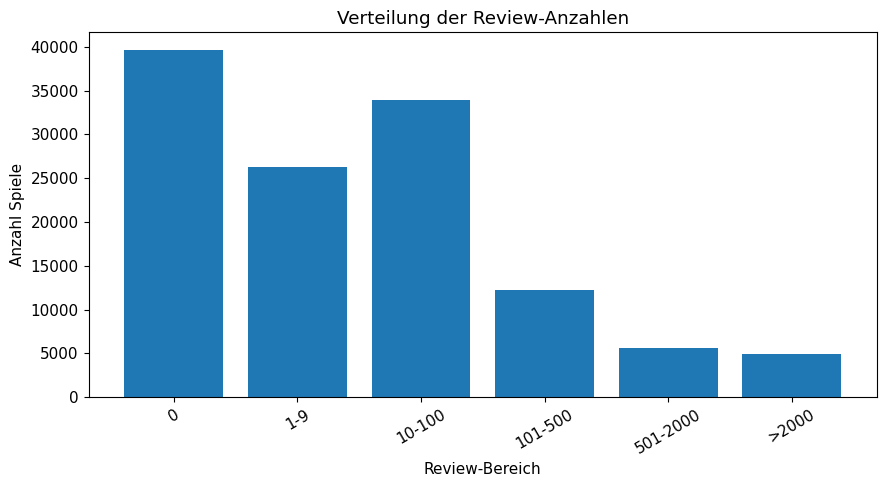

In [35]:
# Review-Verteilung
review_bins = [
    ("0", (df_raw["Total_reviews"] == 0).sum()),
    ("1-9", ((df_raw["Total_reviews"] >= 1) & (df_raw["Total_reviews"] < 10)).sum()),
    ("10-100", ((df_raw["Total_reviews"] >= 10) & (df_raw["Total_reviews"] <= 100)).sum()),
    ("101-500", ((df_raw["Total_reviews"] > 100) & (df_raw["Total_reviews"] <= 500)).sum()),
    ("501-2000", ((df_raw["Total_reviews"] > 500) & (df_raw["Total_reviews"] <= 2000)).sum()),
    (">2000", (df_raw["Total_reviews"] > 2000).sum()),
]

labels, counts = zip(*review_bins)

plt.figure(figsize=(9, 5))
plt.bar(labels, counts)
plt.title("Verteilung der Review-Anzahlen")
plt.xlabel("Review-Bereich")
plt.ylabel("Anzahl Spiele")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 5. Datensatz filtern

Für das Projekt werden nur Spiele betrachtet, die folgende Bedingungen erfüllen:

- Indie-Spiel
- Preis größer als 0
- Anzahl Reviews zwischen 10 und 2000

Warum dieser Filter sinnvoll ist:

- Spiele mit 0 Reviews liefern kaum Information.
- Sehr große Spiele mit extrem vielen Reviews sind Ausreißer.
- Der Fokus liegt auf Indie-Spielen.


In [36]:
df_raw["Price"] = pd.to_numeric(df_raw["Price"], errors="coerce").fillna(0)

indie_mask = df_raw["Tags"].astype(str).str.contains("Indie", case=False, na=False)
paid_mask = df_raw["Price"] > 0
reviews_mask = (df_raw["Total_reviews"] >= 10) & (df_raw["Total_reviews"] <= 2000)

df = df_raw[indie_mask & paid_mask & reviews_mask].copy().reset_index(drop=True)

print(f"Gesamter Datensatz: {len(df_raw):,} Spiele")
print(f"Gefilterter Datensatz: {len(df):,} Spiele")
print("\nZielvariable nach Filter:")
print(df["Total_reviews"].describe().round(2))


Gesamter Datensatz: 122,611 Spiele
Gefilterter Datensatz: 27,083 Spiele

Zielvariable nach Filter:
count    27083.00
mean       174.93
std        316.85
min         10.00
25%         20.00
50%         47.00
75%        157.00
max       1998.00
Name: Total_reviews, dtype: float64


## 6. Explorative Datenanalyse

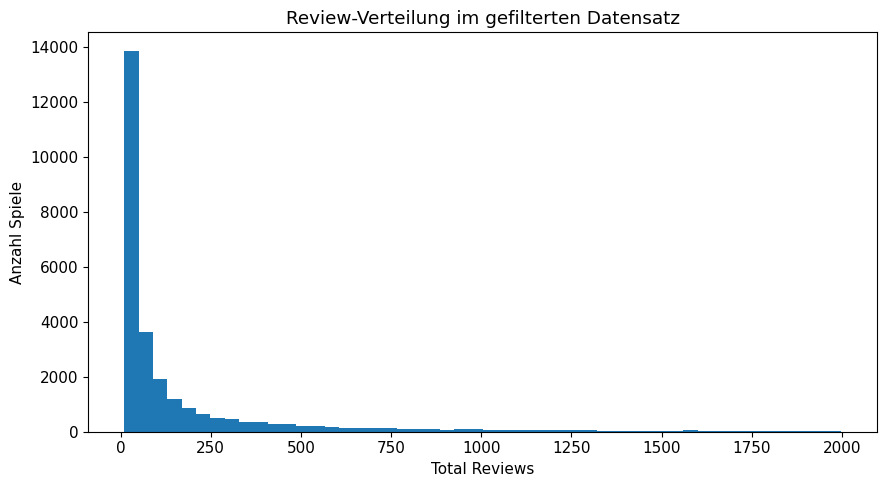

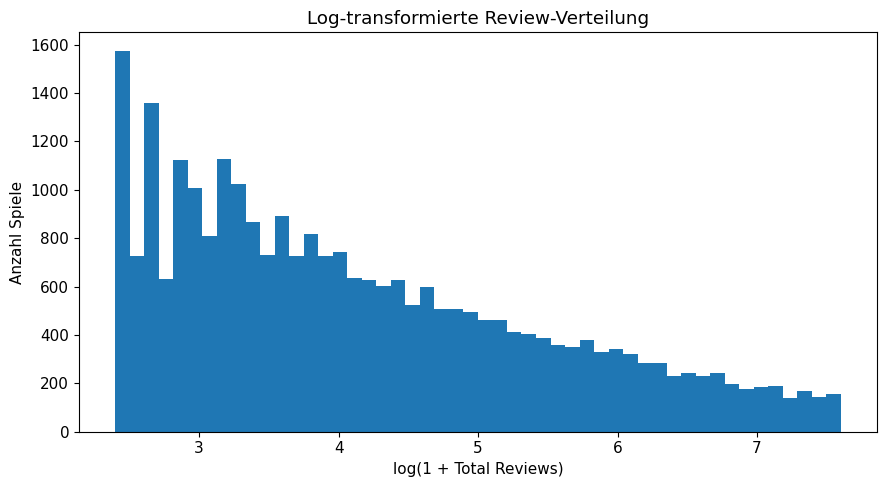

In [37]:
plt.figure(figsize=(9, 5))
plt.hist(df["Total_reviews"], bins=50)
plt.title("Review-Verteilung im gefilterten Datensatz")
plt.xlabel("Total Reviews")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df["Total_reviews"]), bins=50)
plt.title("Log-transformierte Review-Verteilung")
plt.xlabel("log(1 + Total Reviews)")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()


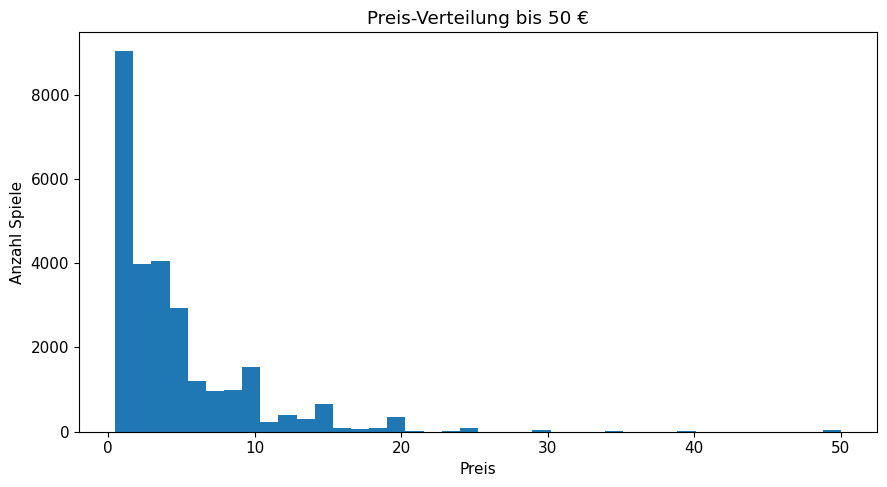

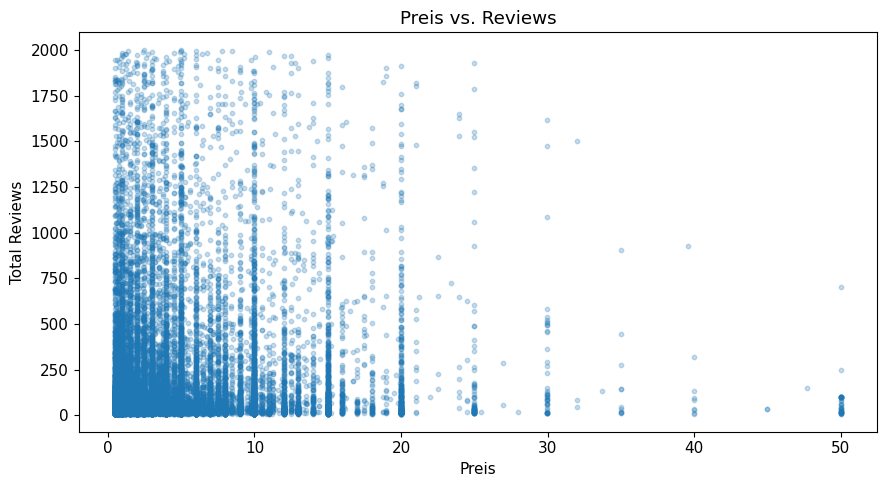

In [38]:
plt.figure(figsize=(9, 5))
plt.hist(df["Price"].clip(upper=50), bins=40)
plt.title("Preis-Verteilung bis 50 €")
plt.xlabel("Preis")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(df["Price"].clip(upper=50), df["Total_reviews"], alpha=0.25, s=10)
plt.title("Preis vs. Reviews")
plt.xlabel("Preis")
plt.ylabel("Total Reviews")
plt.tight_layout()
plt.show()


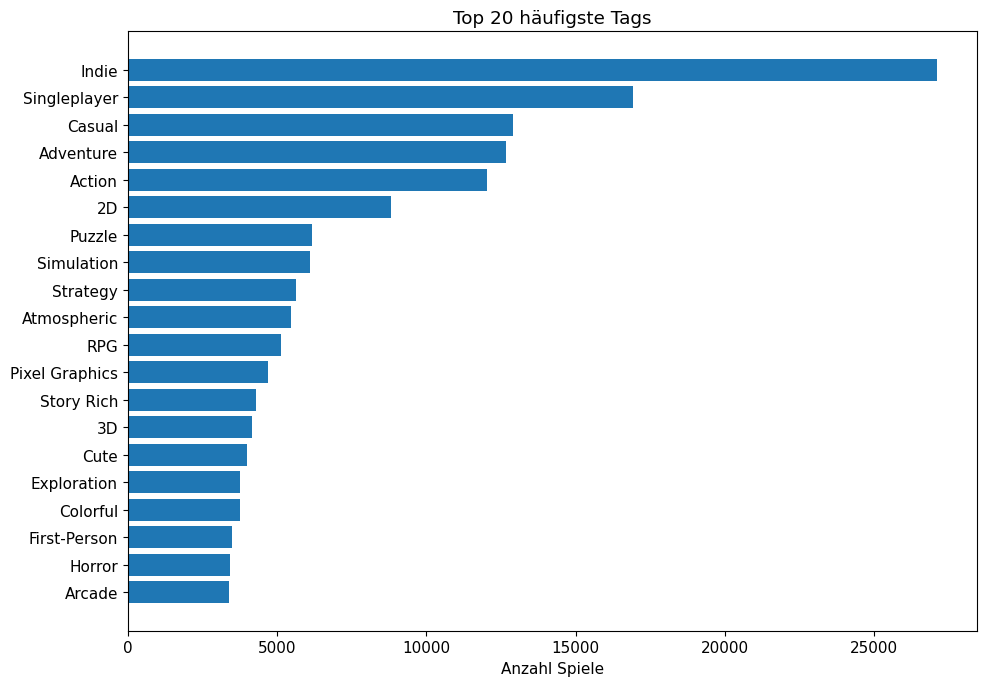

,count
Tags,
Indie,27083
Singleplayer,16920
Casual,12903
Adventure,12671
Action,12036
2D,8822
Puzzle,6169
Simulation,6107
Strategy,5622


In [39]:
all_tags = df["Tags"].dropna().astype(str).str.split(",").explode().str.strip()
top_tags = all_tags.value_counts().head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_tags.index[::-1], top_tags.values[::-1])
plt.title("Top 20 häufigste Tags")
plt.xlabel("Anzahl Spiele")
plt.tight_layout()
plt.show()

top_tags


## 7. Feature Engineering

Es werden Text-Features und numerische Features erstellt.

**Text-Features:**

- Spielbeschreibung
- Tags
- Genres
- Kategorien

**Numerische Features:**

- Preis
- Anzahl Achievements
- Anzahl Tags
- Länge der Beschreibung
- Plattformen
- Release-Jahr


In [40]:
# Text kombinieren
df["text_combined"] = (
    df["About the game"].fillna("").astype(str) + " " +
    df["Tags"].fillna("").astype(str) + " " +
    df["Genres"].fillna("").astype(str) + " " +
    df["Categories"].fillna("").astype(str)
)

# Zielvariable vorbereiten
df["Total_reviews"] = pd.to_numeric(df["Total_reviews"], errors="coerce").fillna(0)
df["Log_total_reviews"] = np.log1p(df["Total_reviews"])

# Numerische Features
df["Price"] = pd.to_numeric(df["Price"], errors="coerce").fillna(0)

df["Achievements_count"] = pd.to_numeric(df["Achievements"], errors="coerce").fillna(0)
df["Has_achievements"] = (df["Achievements_count"] > 0).astype(int)

df["Num_tags"] = df["Tags"].fillna("").astype(str).apply(
    lambda x: len([tag for tag in x.split(",") if tag.strip()]) if x else 0
)

df["Desc_length"] = df["About the game"].fillna("").astype(str).apply(len)

df["Is_windows"] = df["Windows"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)
df["Is_mac"] = df["Mac"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)
df["Is_linux"] = df["Linux"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)

df["Release_year"] = pd.to_datetime(df["Release date"], errors="coerce").dt.year
df["Release_year"] = df["Release_year"].fillna(df["Release_year"].median())

df["Release_year"] = pd.to_datetime(
    df["Release date"],
    format="%b %d, %Y",
    errors="coerce"
).dt.year

df["Release_year"] = df["Release_year"].fillna(df["Release_year"].median())

print(df["Release_year"].head())
print(df["Release_year"].isna().sum())

numeric_features = [
    "Price",
    # "Achievements_count",
    "Has_achievements",
    "Num_tags",
    "Desc_length",
    "Is_windows",
    "Is_mac",
    "Is_linux",
    "Release_year"
]

df[numeric_features + ["Total_reviews", "Log_total_reviews"]].describe().round(2)

0    2021
1    2019
2    2023
3    2021
4    2024
Name: Release_year, dtype: int32
0


,Price,Has_achievements,Num_tags,Desc_length,Is_windows,Is_mac,Is_linux,Release_year,Total_reviews,Log_total_reviews
count,27083.00,27083.00,27083.00,27083.00,27083.0,27083.00,27083.00,27083.00,27083.00,27083.00
mean,4.63,0.69,13.46,1285.08,1.0,0.26,0.18,2019.63,174.93,4.17
std,7.07,0.46,6.16,914.65,0.0,0.44,0.39,3.22,316.85,1.33
min,0.49,0.00,1.00,0.00,1.0,0.00,0.00,1997.00,10.00,2.40
25%,0.99,0.00,7.00,685.00,1.0,0.00,0.00,2017.00,20.00,3.04
50%,2.99,1.00,15.00,1077.00,1.0,0.00,0.00,2020.00,47.00,3.87
75%,5.99,1.00,20.00,1624.00,1.0,1.00,0.00,2022.00,157.00,5.06
max,269.99,1.00,21.00,25646.00,1.0,1.00,1.00,2025.00,1998.00,7.60


In [41]:
# -----------------------------
# ResNet vorbereiten
# -----------------------------
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#weights = ResNet50_Weights.DEFAULT
#resnet = resnet50(weights=weights)
#resnet.fc = torch.nn.Identity()
#resnet = resnet.to(device)
#resnet.eval()

#transform = weights.transforms()

In [42]:
 #def load_image(url):
     #try:
         #if pd.isna(url) or str(url).strip() == "":
           #  return None

         #response = requests.get(
            # url,
            # timeout=10,
            # headers={"User-Agent": "Mozilla/5.0"}
         #)

         #response.raise_for_status()

         #image = Image.open(BytesIO(response.content)).convert("RGB")
         #return image

    # except Exception:
         #return None


 #def extract_resnet_feature(url):
   #  image = load_image(url)

    # if image is None:
     #    return np.zeros(2048, dtype=np.float32)

    # image = transform(image).unsqueeze(0).to(device)

    # with torch.no_grad():
   #     feature = resnet(image)

  #  return feature.squeeze(0).cpu().numpy().astype(np.float32)

In [43]:
#image_features = []

#for i, url in enumerate(df["Header image"]):
#    feature = extract_resnet_feature(url)
#    image_features.append(feature)

#    if (i + 1) % 100 == 0:
#        print(f"{i + 1} von {len(df)} Bildern verarbeitet")

#image_features = np.vstack(image_features).astype(np.float32)

#print("ResNet-Features erstellt:", image_features.shape)

#np.save("resnet_features.npy", image_features)

In [44]:
image_features = np.load("resnet_features.npy")
print("ResNet-Features geladen:", image_features.shape)

ResNet-Features geladen: (27083, 2048)


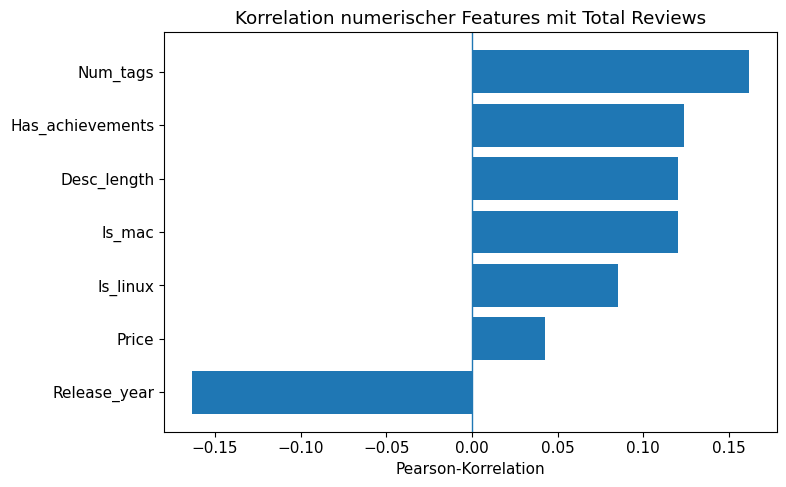

,Total_reviews
Release_year,-0.163509
Price,0.042328
Is_linux,0.085400
Is_mac,0.120064
Desc_length,0.120336
Has_achievements,0.123810
Num_tags,0.161755
Is_windows,NaN


In [45]:
# normal reviews correlation

corr_reviews = df[numeric_features + ["Total_reviews"]].corr(numeric_only=True)["Total_reviews"]
corr_reviews = corr_reviews.drop("Total_reviews").sort_values()

plt.figure(figsize=(8, 5))
plt.barh(corr_reviews.index, corr_reviews.values)
plt.axvline(0, linewidth=1)
plt.title("Korrelation numerischer Features mit Total Reviews")
plt.xlabel("Pearson-Korrelation")
plt.tight_layout()
plt.show()

corr_reviews

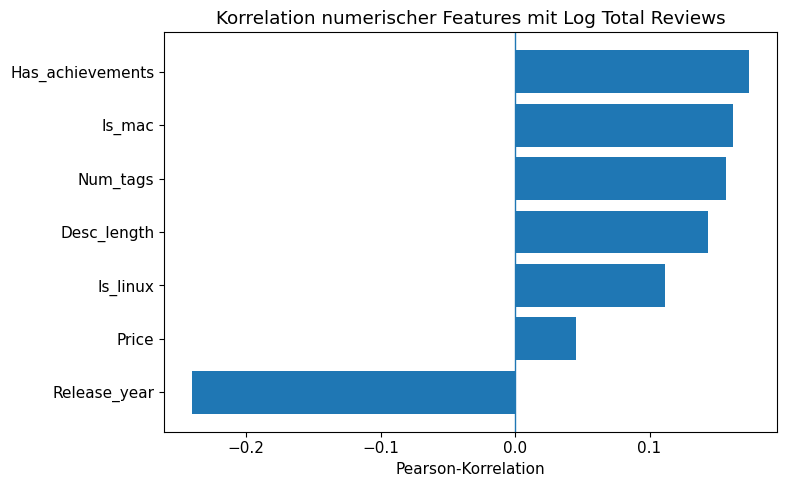

,Log_total_reviews
Release_year,-0.240474
Price,0.045353
Is_linux,0.111209
Desc_length,0.143824
Num_tags,0.157235
Is_mac,0.161941
Has_achievements,0.174084
Is_windows,NaN


In [46]:
# log reviews correlation

corr_log_reviews = df[numeric_features + ["Log_total_reviews"]].corr(numeric_only=True)["Log_total_reviews"]
corr_log_reviews = corr_log_reviews.drop("Log_total_reviews").sort_values()

plt.figure(figsize=(8, 5))
plt.barh(corr_log_reviews.index, corr_log_reviews.values)
plt.axvline(0, linewidth=1)
plt.title("Korrelation numerischer Features mit Log Total Reviews")
plt.xlabel("Pearson-Korrelation")
plt.tight_layout()
plt.show()

corr_log_reviews

## 8. Train/Test-Split ohne Data Leakage

Wichtig: Der Train/Test-Split passiert **vor** TF-IDF.

Dadurch sieht der TF-IDF-Vektorisierer beim Lernen nur die Trainingsdaten und nicht die Testdaten.


In [47]:
# Text-, numerische und Bild-Features vorbereiten
X_text = df["text_combined"]
X_num = df[numeric_features].fillna(0)
X_image = image_features

y = np.log1p(df["Total_reviews"])

# Text, numerische Features, Bildfeatures und Zielvariable gemeinsam aufteilen
(
    X_text_train,
    X_text_test,
    X_num_train,
    X_num_test,
    X_image_train,
    X_image_test,
    y_train,
    y_test
) = train_test_split(
    X_text,
    X_num,
    X_image,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


In [48]:
# TF-IDF nur auf Trainingsdaten fitten
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    stop_words="english"
)

X_train_text_tfidf = tfidf.fit_transform(X_text_train)
X_test_text_tfidf = tfidf.transform(X_text_test)

# Numerische Features skalieren
numeric_scaler = StandardScaler()

X_train_num_scaled = numeric_scaler.fit_transform(X_num_train)
X_test_num_scaled = numeric_scaler.transform(X_num_test)

# ResNet-Bildfeatures skalieren
image_scaler = StandardScaler()

X_train_image_scaled = image_scaler.fit_transform(X_image_train)
X_test_image_scaled = image_scaler.transform(X_image_test)

# Text + numerische Features + ResNet-Bildfeatures kombinieren
X_train = hstack([
    X_train_text_tfidf,
    csr_matrix(X_train_num_scaled),
    csr_matrix(X_train_image_scaled)
])

X_test = hstack([
    X_test_text_tfidf,
    csr_matrix(X_test_num_scaled),
    csr_matrix(X_test_image_scaled)
])

print("Text-Features:", X_train_text_tfidf.shape)
print("Numerische Features:", X_train_num_scaled.shape)
print("ResNet-Features:", X_train_image_scaled.shape)

print("Feature-Matrix Training:", X_train.shape)
print("Feature-Matrix Test:", X_test.shape)

Text-Features: (21666, 3000)
Numerische Features: (21666, 8)
ResNet-Features: (21666, 2048)
Feature-Matrix Training: (21666, 5056)
Feature-Matrix Test: (5417, 5056)


## 9. Hilfsfunktion für Evaluation

In [49]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """Trainiert ein Modell und berechnet Metriken auf Original-Review-Skala."""
    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    # Rücktransformation von log(1 + reviews) zu reviews
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)

    # Negative Vorhersagen vermeiden
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    result = {
        "Modell": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return result, y_true, y_pred


## 10. Modelle trainieren

### 10.1 Linear Regression / Ridge Regression

Ridge ist eine regularisierte lineare Regression.  
Sie ist stabiler als eine einfache Linear Regression, besonders bei sehr vielen TF-IDF-Features.


In [50]:
results = {}
predictions = {}

ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)

result, y_true, y_pred_ridge = evaluate_model(
    "Linear Regression (Ridge)",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

results["Linear Regression (Ridge)"] = result
predictions["Linear Regression (Ridge)"] = y_pred_ridge

print(result)


{'Modell': 'Linear Regression (Ridge)', 'MAE': 135.67248044847813, 'RMSE': np.float64(291.3807739063008), 'R2': 0.12641156618724592}


### 10.2 Random Forest Regressor

Random Forest kann nichtlineare Zusammenhänge lernen.  
Er ist aber bei sehr vielen Textfeatures oft langsamer als lineare Modelle oder XGBoost.


In [51]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=3,
    max_features=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

result, y_true, y_pred_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

results["Random Forest"] = result
predictions["Random Forest"] = y_pred_rf

print(result)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 16.9min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 45.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.5s


{'Modell': 'Random Forest', 'MAE': 130.17503720280843, 'RMSE': np.float64(293.0184600592622), 'R2': 0.11656407942976355}


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.4s finished


### 10.3 XGBoost Regressor

In [52]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1
    )

    result, y_true, y_pred_xgb = evaluate_model(
        "XGBoost",
        xgb_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["XGBoost"] = result
    predictions["XGBoost"] = y_pred_xgb

    print(result)
else:
    print("XGBoost wurde übersprungen, weil das Paket nicht installiert ist.")


{'Modell': 'XGBoost', 'MAE': 123.21665318478335, 'RMSE': np.float64(276.16681880881805), 'R2': 0.21525585322689644}


Distilbert

In [53]:
# ============================================================
# DistilBERT Regression Model for Steam Sales Prediction
# ============================================================

# !pip install transformers torch

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [54]:
# ------------------------------------------------------------
# 1. Better text for BERT
# Important: Tags/Genres/Categories first, because they are very informative
# ------------------------------------------------------------

df["bert_text"] = (
    "Tags: " + df["Tags"].fillna("").astype(str) + " " +
    "Genres: " + df["Genres"].fillna("").astype(str) + " " +
    "Categories: " + df["Categories"].fillna("").astype(str) + " " +
    "Description: " + df["About the game"].fillna("").astype(str)
)

X_text_bert = df["bert_text"]
y_bert = np.log1p(df["Total_reviews"])

In [55]:
# ------------------------------------------------------------
# 2. Same train/test split logic as other models
# ------------------------------------------------------------

X_text_train_full, X_text_test_bert, X_num_train_full, X_num_test_bert, y_train_full, y_test_bert = train_test_split(
    X_text_bert,
    X_num,
    y_bert,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Validation split from training data
X_text_train_bert, X_text_val_bert, X_num_train_bert, X_num_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_text_train_full,
    X_num_train_full,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [56]:
# ------------------------------------------------------------
# 3. Scale numeric features
# Fit scaler ONLY on training data
# ------------------------------------------------------------

scaler_bert = StandardScaler()

X_num_train_bert_scaled = scaler_bert.fit_transform(X_num_train_bert)
X_num_val_bert_scaled = scaler_bert.transform(X_num_val_bert)
X_num_test_bert_scaled = scaler_bert.transform(X_num_test_bert)

In [57]:
# ------------------------------------------------------------
# 4. Dataset class
# ------------------------------------------------------------

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class SteamBertDataset(Dataset):
    def __init__(self, texts, numeric_features, targets, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.numeric_features = torch.tensor(numeric_features, dtype=torch.float32)
        self.targets = torch.tensor(targets.values, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "numeric_features": self.numeric_features[idx],
            "target": self.targets[idx]
        }

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [58]:
# ------------------------------------------------------------
# 5. DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 16

train_dataset = SteamBertDataset(
    X_text_train_bert,
    X_num_train_bert_scaled,
    y_train_bert,
    tokenizer,
    max_length=256
)

val_dataset = SteamBertDataset(
    X_text_val_bert,
    X_num_val_bert_scaled,
    y_val_bert,
    tokenizer,
    max_length=256
)

test_dataset = SteamBertDataset(
    X_text_test_bert,
    X_num_test_bert_scaled,
    y_test_bert,
    tokenizer,
    max_length=256
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [59]:
# ------------------------------------------------------------
# 6. DistilBERT regression model
# ------------------------------------------------------------

class DistilBertRegression(nn.Module):
    def __init__(self, num_numeric_features):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        self.regressor = nn.Sequential(
            nn.Linear(768 + num_numeric_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask, numeric_features):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = bert_output.last_hidden_state[:, 0, :]

        combined = torch.cat(
            [cls_output, numeric_features],
            dim=1
        )

        prediction = self.regressor(combined).squeeze(1)
        return prediction


model = DistilBertRegression(
    num_numeric_features=X_num_train_bert_scaled.shape[1]
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [60]:
import os

checkpoint_path = "distilbert_model.pt"

if os.path.exists(checkpoint_path):
    print("Checkpoint gefunden, Training wird übersprungen.")
else:
    # ------------------------------------------------------------
    # 7. Training with validation + best model saving
    # ------------------------------------------------------------

    EPOCHS = 5

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            numeric_features_batch = batch["numeric_features"].to(device)
            target = batch["target"].to(device)

            prediction = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                numeric_features=numeric_features_batch
            )

            loss = criterion(prediction, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                numeric_features_batch = batch["numeric_features"].to(device)
                target = batch["target"].to(device)

                prediction = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    numeric_features=numeric_features_batch
                )

                loss = criterion(prediction, target)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            print("Best model updated")


Epoch 1/5 | Train Loss: 2.7161 | Val Loss: 1.3811
Best model updated
Epoch 2/5 | Train Loss: 1.2995 | Val Loss: 1.1279
Best model updated
Epoch 3/5 | Train Loss: 1.1595 | Val Loss: 1.1638
Epoch 4/5 | Train Loss: 1.0422 | Val Loss: 1.1220
Best model updated
Epoch 5/5 | Train Loss: 0.9328 | Val Loss: 1.1310


In [61]:
# ------------------------------------------------------------
# 8. Load best validation model
# ------------------------------------------------------------

if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
else:
    model.load_state_dict(best_model_state)
    model.eval()
    torch.save(model.state_dict(), checkpoint_path)
    print("DistilBERT-Checkpoint gespeichert:", checkpoint_path)


DistilBERT-Checkpoint gespeichert: distilbert_model.pt


In [62]:
# ------------------------------------------------------------
# 9. Test evaluation
# ------------------------------------------------------------

distilbert_preds_log = []
distilbert_true_log = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        numeric_features_batch = batch["numeric_features"].to(device)

        prediction = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            numeric_features=numeric_features_batch
        )

        distilbert_preds_log.extend(prediction.cpu().numpy())
        distilbert_true_log.extend(batch["target"].numpy())

distilbert_preds_log = np.array(distilbert_preds_log)
distilbert_true_log = np.array(distilbert_true_log)

In [63]:
# ------------------------------------------------------------
# 10. Metrics on log scale
# ------------------------------------------------------------

mae_log = mean_absolute_error(distilbert_true_log, distilbert_preds_log)
rmse_log = np.sqrt(mean_squared_error(distilbert_true_log, distilbert_preds_log))
r2_log = r2_score(distilbert_true_log, distilbert_preds_log)

print("DistilBERT results on log scale:")
print("MAE log:", mae_log)
print("RMSE log:", rmse_log)
print("R² log:", r2_log)

DistilBERT results on log scale:
MAE log: 0.8204944133758545
RMSE log: 1.0463878010340588
R² log: 0.37775135040283203


In [64]:
# ------------------------------------------------------------
# 11. Metrics on original review scale
# ------------------------------------------------------------

y_true_distilbert = np.expm1(distilbert_true_log)
y_pred_distilbert = np.expm1(distilbert_preds_log)

# Avoid negative predictions after transformation
y_pred_distilbert = np.maximum(y_pred_distilbert, 0)

mae = mean_absolute_error(y_true_distilbert, y_pred_distilbert)
rmse = np.sqrt(mean_squared_error(y_true_distilbert, y_pred_distilbert))
r2 = r2_score(y_true_distilbert, y_pred_distilbert)

print("DistilBERT results on original review scale:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

DistilBERT results on original review scale:
MAE: 127.79887390136719
RMSE: 271.51612808910636
R²: 0.2414637804031372


In [65]:
# ------------------------------------------------------------
# 12. Add DistilBERT to your comparison table
# ------------------------------------------------------------

results["DistilBERT"] = {
    "Modell": "DistilBERT",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

predictions["DistilBERT"] = y_pred_distilbert

results_df = pd.DataFrame(results.values())
results_df = results_df.sort_values("MAE").reset_index(drop=True)

display(results_df.round(3))

,Modell,MAE,RMSE,R2
0,XGBoost,123.217,276.167,0.215
1,DistilBERT,127.799,271.516,0.241
2,Random Forest,130.175,293.018,0.117
3,Linear Regression (Ridge),135.672,291.381,0.126


## 11. Modellvergleich

In [66]:
results_df = pd.DataFrame(results.values())
results_df = results_df.sort_values("MAE").reset_index(drop=True)

print("Modellvergleich auf Original-Review-Skala:")
display(results_df.round(3))

best_model_name = results_df.iloc[0]["Modell"]
print(f"🏆 Bestes Modell nach MAE: {best_model_name}")


Modellvergleich auf Original-Review-Skala:


,Modell,MAE,RMSE,R2
0,XGBoost,123.217,276.167,0.215
1,DistilBERT,127.799,271.516,0.241
2,Random Forest,130.175,293.018,0.117
3,Linear Regression (Ridge),135.672,291.381,0.126


🏆 Bestes Modell nach MAE: XGBoost


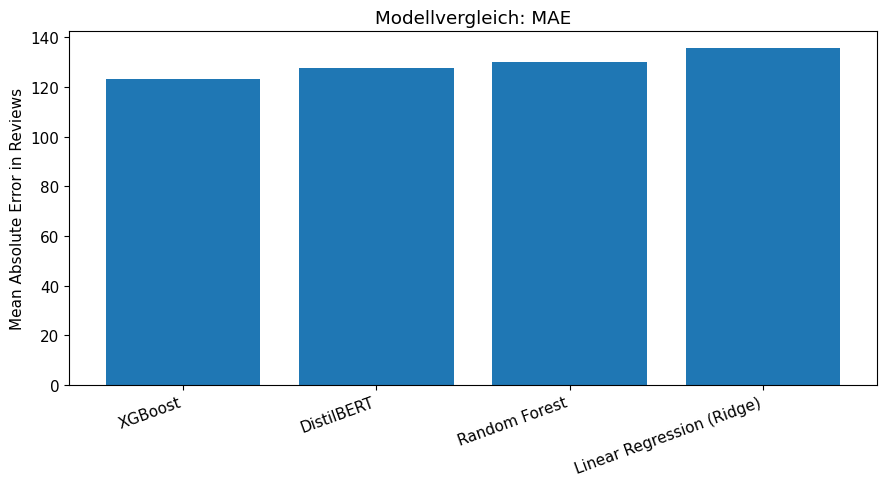

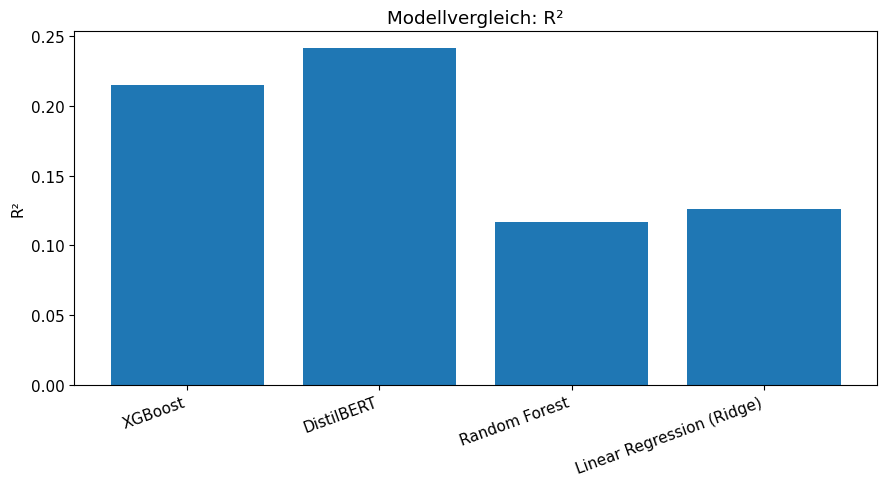

In [67]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Modell"], results_df["MAE"])
plt.title("Modellvergleich: MAE")
plt.ylabel("Mean Absolute Error in Reviews")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Modell"], results_df["R2"])
plt.title("Modellvergleich: R²")
plt.ylabel("R²")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 12. Visualisierung: echte vs. vorhergesagte Reviews

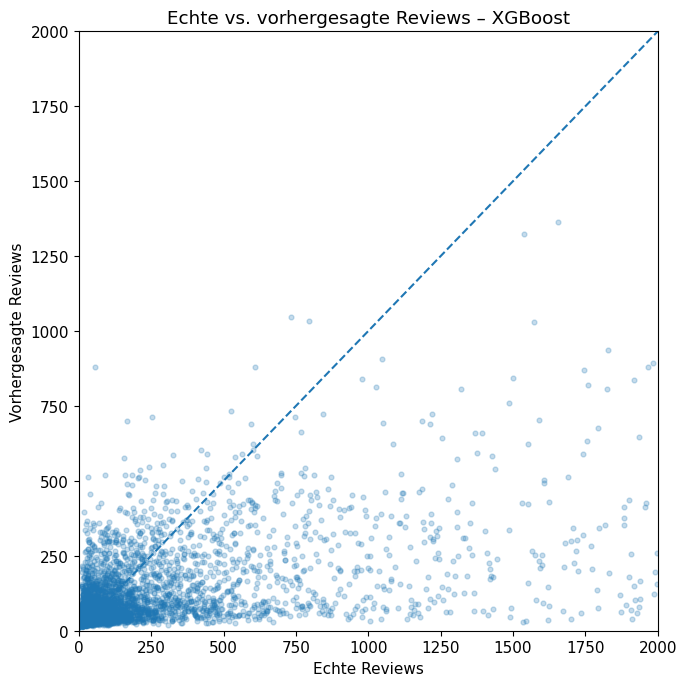

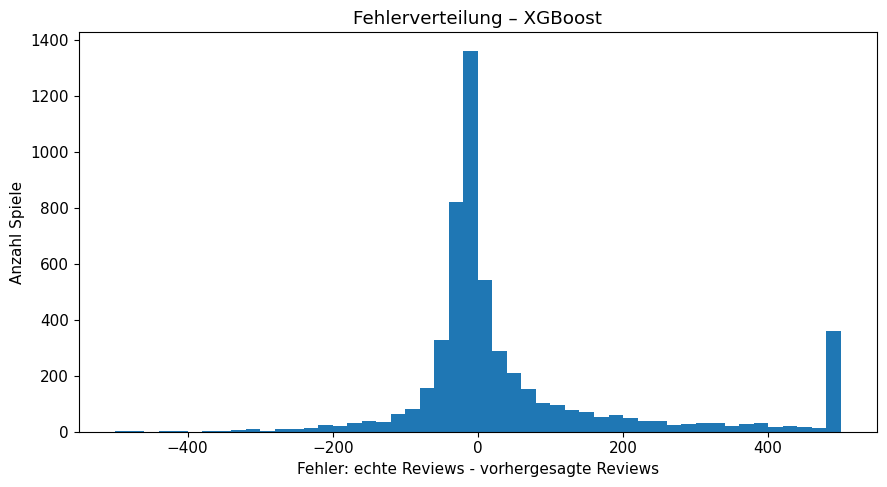

In [68]:
best_pred = predictions[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_true, best_pred, alpha=0.25, s=12)
plt.plot([0, 2000], [0, 2000], linestyle="--")
plt.title(f"Echte vs. vorhergesagte Reviews – {best_model_name}")
plt.xlabel("Echte Reviews")
plt.ylabel("Vorhergesagte Reviews")
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.tight_layout()
plt.show()

residuals = y_true - best_pred

plt.figure(figsize=(9, 5))
plt.hist(np.clip(residuals, -500, 500), bins=50)
plt.title(f"Fehlerverteilung – {best_model_name}")
plt.xlabel("Fehler: echte Reviews - vorhergesagte Reviews")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()


## 13. Feature Importance

Bei XGBoost und Random Forest können Feature Importances betrachtet werden.  
Bei Ridge betrachten wir die absoluten Koeffizienten.

Wichtig: Feature Importance zeigt nur, welche Features im Modell wichtig waren.  
Sie beweist nicht automatisch einen kausalen Zusammenhang.


Feature-Namen: 5056
X_train-Spalten: 5056
Importances: 5056


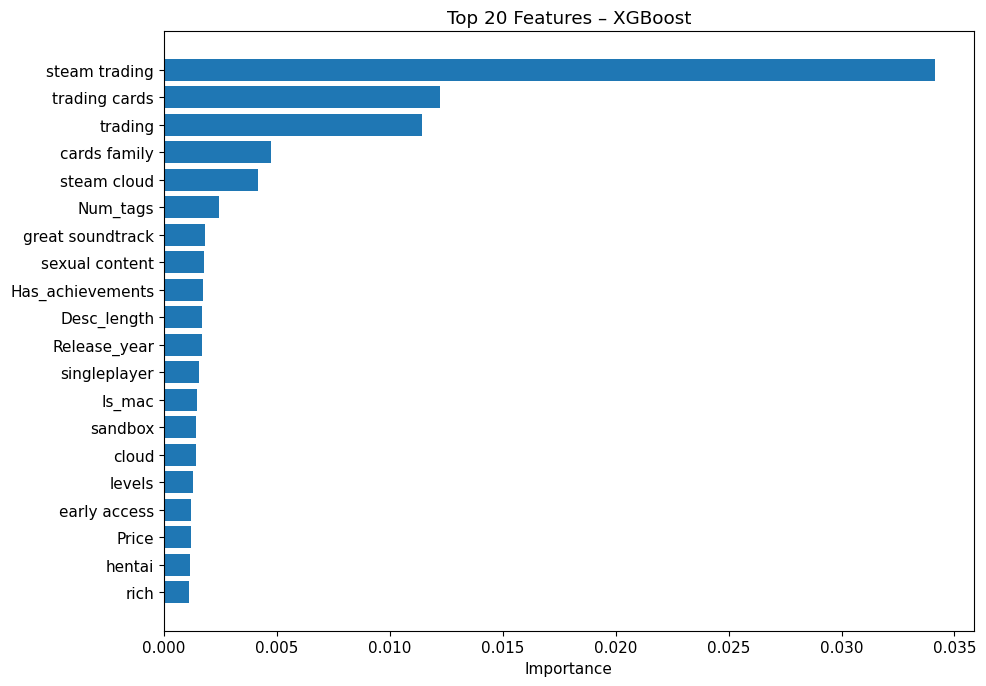

,Feature,Importance
2513,steam trading,0.034144
2733,trading cards,0.012215
2732,trading,0.011428
401,cards family,0.004739
2511,steam cloud,0.004149
3002,Num_tags,0.002416
1216,great soundtrack,0.001835
2352,sexual content,0.001758
3001,Has_achievements,0.001734
3003,Desc_length,0.001686


In [73]:
n_resnet = 2048

resnet_feature_names = [
    f"ResNet_{i}" for i in range(n_resnet)
]

feature_names = (
    list(tfidf.get_feature_names_out())
    + numeric_features
    + resnet_feature_names
)

print("Feature-Namen:", len(feature_names))
print("X_train-Spalten:", X_train.shape[1])

def show_top_features(model_name, top_n=20):
    if model_name == "XGBoost" and XGBOOST_AVAILABLE:
        importance = xgb_model.feature_importances_

    elif model_name == "Random Forest":
        importance = rf_model.feature_importances_

    elif model_name == "Linear Regression (Ridge)":
        importance = np.abs(np.ravel(ridge_model.coef_))

    else:
        print("Keine Feature Importance verfügbar.")
        return None

    print("Importances:", len(importance))

    if len(feature_names) != len(importance):
        raise ValueError(
            f"{len(feature_names)} Feature-Namen, "
            f"aber {len(importance)} Importances."
        )

    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(
        "Importance",
        ascending=False
    ).head(top_n)

    plt.figure(figsize=(10, 7))
    plt.barh(fi["Feature"][::-1], fi["Importance"][::-1])
    plt.title(f"Top {top_n} Features – {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return fi

top_features = show_top_features(best_model_name, top_n=20)
top_features

## 14. Fehleranalyse

In [74]:
error_df = pd.DataFrame({
    "Name": df.loc[X_text_test.index, "Name"].values if "Name" in df.columns else X_text_test.index.astype(str),
    "Echte Reviews": y_true,
    "Vorhergesagte Reviews": best_pred,
    "Absoluter Fehler": np.abs(y_true - best_pred),
    "Text": X_text_test.values
})

error_df = error_df.sort_values("Absoluter Fehler", ascending=False)

print("Top 10 größte Fehler:")
display(error_df[["Name", "Echte Reviews", "Vorhergesagte Reviews", "Absoluter Fehler"]].head(10).round(1))


Top 10 größte Fehler:


,Name,Echte Reviews,Vorhergesagte Reviews,Absoluter Fehler
24404,Small Saga,1911.0,38.900002,1872.1
13531,Cultivation Story: Reincarnation,1930.0,60.400002,1869.6
17468,Genesis Noir,1988.0,122.800003,1865.2
16594,KIDS,1934.0,78.800003,1855.2
4347,The Imperial Gatekeeper,1997.0,154.800003,1842.2
5001,The Political Process,1908.0,68.500000,1839.5
9577,Everhood 2,1938.0,104.599998,1833.4
1175,Bad Guys at School,1920.0,103.800003,1816.2
14529,Spark the Electric Jester 3,1873.0,64.000000,1809.0
27068,Subsurface Circular,1889.0,87.199997,1801.8


## 15. Demo: Reviews für ein neues Spiel vorhersagen

Die Funktion nutzt das beste trainierte Modell aus dem Vergleich.


In [77]:
from scipy.sparse import hstack, csr_matrix
import numpy as np
import pandas as pd

def predict_reviews(
    description,
    tags,
    genres="",
    categories="",
    price=9.99,
    achievements=0,
    windows=True,
    mac=False,
    linux=False,
    release_year=2026,
    image_features=None
):
    # ------------------------------------------------------------
    # 1. Text vorbereiten
    # ------------------------------------------------------------
    text = f"{description} {tags} {genres} {categories}"
    X_text_new = tfidf.transform([text])

    # ------------------------------------------------------------
    # 2. Numerische Features vorbereiten
    # ------------------------------------------------------------
    num_values = pd.DataFrame([{
        "Price": price,
        "Has_achievements": int(achievements > 0),
        "Num_tags": len([
            tag for tag in tags.split(",")
            if tag.strip()
        ]),
        "Desc_length": len(description),
        "Is_windows": int(windows),
        "Is_mac": int(mac),
        "Is_linux": int(linux),
        "Release_year": release_year
    }])[numeric_features]

    # Dein Scaler heißt numeric_scaler, nicht scaler
    X_num_new = numeric_scaler.transform(num_values)

    # ------------------------------------------------------------
    # 3. Optionale ResNet-Features
    # ------------------------------------------------------------
    if image_features is None:
        # Kein Bild vorhanden:
        # 0 entspricht bei StandardScaler ungefähr dem Mittelwert
        # der Trainings-Bildfeatures.
        X_image_new = np.zeros((1, 2048), dtype=np.float32)
    else:
        X_image_new = np.asarray(
            image_features,
            dtype=np.float32
        ).reshape(1, -1)

        if X_image_new.shape[1] != 2048:
            raise ValueError(
                f"Es werden 2048 ResNet-Features erwartet, "
                f"übergeben wurden aber {X_image_new.shape[1]}."
            )

        # Die echten ResNet-Features müssen genauso skaliert werden
        # wie beim Training.
        X_image_new = image_scaler.transform(X_image_new)

    # ------------------------------------------------------------
    # 4. Features in derselben Reihenfolge wie beim Training verbinden
    # TF-IDF + numerische Features + ResNet-Features
    # ------------------------------------------------------------
    X_new = hstack([
        X_text_new,
        csr_matrix(X_num_new),
        csr_matrix(X_image_new)
    ]).tocsr()

    if X_new.shape[1] != X_train.shape[1]:
        raise ValueError(
            f"Das neue Beispiel hat {X_new.shape[1]} Features, "
            f"das Modell erwartet aber {X_train.shape[1]}."
        )

    # ------------------------------------------------------------
    # 5. Bestes Modell auswählen
    # ------------------------------------------------------------
    if best_model_name == "XGBoost" and XGBOOST_AVAILABLE:
        model = xgb_model

    elif best_model_name == "Random Forest":
        model = rf_model

    elif best_model_name == "Linear Regression (Ridge)":
        model = ridge_model

    else:
        raise ValueError(
            f"Unbekanntes bestes Modell: {best_model_name}"
        )

    # ------------------------------------------------------------
    # 6. Vorhersage
    # ------------------------------------------------------------
    pred_log = model.predict(X_new)[0]

    # Nur korrekt, wenn y beim Training mit np.log1p transformiert wurde
    pred_log = np.clip(pred_log, 0, 10)
    pred_reviews = max(0, np.expm1(pred_log))

    return round(float(pred_reviews))


examples = [
    {
        "description": (
            "A dark atmospheric horror game with puzzle solving "
            "and survival mechanics."
        ),
        "tags": (
            "Horror, Survival, Atmospheric, Puzzle, "
            "Indie, Singleplayer"
        ),
        "genres": "Adventure, Indie",
        "price": 14.99
    },
    {
        "description": (
            "A colorful casual 2D platformer with cute characters "
            "and simple controls."
        ),
        "tags": "Casual, Platformer, Colorful, Cute, Indie",
        "genres": "Casual, Indie",
        "price": 4.99
    },
    {
        "description": (
            "Deep turn-based strategy RPG with complex systems, "
            "base building and tactical battles."
        ),
        "tags": (
            "Strategy, RPG, Turn-Based, Base Building, "
            "Tactical, Indie"
        ),
        "genres": "Strategy, RPG, Indie",
        "price": 19.99
    }
]

for example in examples:
    pred = predict_reviews(**example)

    print(
        f"{example['genres']:25s} | "
        f"Preis: {example['price']:5.2f} € | "
        f"Vorhersage: {pred:,} Reviews"
    )

Adventure, Indie          | Preis: 14.99 € | Vorhersage: 128 Reviews
Casual, Indie             | Preis:  4.99 € | Vorhersage: 95 Reviews
Strategy, RPG, Indie      | Preis: 19.99 € | Vorhersage: 140 Reviews


## 16. Fazit

In diesem Notebook wurde ein Machine-Learning-Workflow zur Vorhersage von Steam-Reviews umgesetzt.

### Was wurde gemacht?

- Datensatz geladen und geprüft
- Zielvariable `Total_reviews` erstellt
- Indie-Spiele mit 10 bis 2000 Reviews gefiltert
- Explorative Datenanalyse durchgeführt
- Textfeatures mit TF-IDF erstellt
- Data Leakage vermieden, weil TF-IDF nur auf Trainingsdaten gefittet wurde
- Drei Modelle verglichen:
  - Linear Regression / Ridge
  - Random Forest
  - XGBoost
- Ergebnisse mit MAE, RMSE und R² bewertet
- Feature Importance und Fehleranalyse ergänzt

### Interpretation

Das beste Modell ist das Modell mit dem niedrigsten MAE.  
Der MAE zeigt, um wie viele Reviews das Modell im Durchschnitt danebenliegt.

### Grenzen des Ansatzes

- Reviews sind nur ein Proxy für Sales, keine echten Verkaufszahlen.
- Sehr erfolgreiche Spiele sind schwer vorherzusagen.
- Marketing, Publisher, Wishlists und externe Aufmerksamkeit fehlen im Datensatz.
- Textinformationen allein erklären den Erfolg nur teilweise.

### Nächster sinnvoller Schritt

Als nächstes kann ein Textmodell wie **DistilBERT** getestet werden.  
Dadurch kann geprüft werden, ob ein Sprachmodell die Spielbeschreibung besser versteht als TF-IDF.


In [78]:
print(results_df)

                      Modell         MAE        RMSE        R2
0                    XGBoost  123.216653  276.166819  0.215256
1                 DistilBERT  127.798874  271.516128  0.241464
2              Random Forest  130.175037  293.018460  0.116564
3  Linear Regression (Ridge)  135.672480  291.380774  0.126412


In [81]:
#Speichert die drei trainierten Modelle als Dateien, diese werden für die streamlit app gebraucht
import pickle

xgb_model.get_booster().save_model("model.json")

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("numeric_scaler.pkl", "wb") as f:
    pickle.dump(numeric_scaler, f)

with open("image_scaler.pkl", "wb") as f:
    pickle.dump(image_scaler, f)

with open("ridge.pkl", "wb") as f:
    pickle.dump(ridge_model, f)

with open("rf.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Modelle erfolgreich gespeichert!")

Modelle erfolgreich gespeichert!
